# **기본 알고리즘4 : KNN**

## **1. 환경준비**

### (1) Import

In [1]:
#라이브러리들을 불러오자.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### (2) Data Loading

In [2]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/boston.csv'
data = pd.read_csv(path)
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


|	변수	|	설명	|
|----|----|
|	medv	|	타운별 집값(중위수)	|
|	crim	|	범죄율	|
|	zn	|	25,000 평방피트를 초과 거주지역 비율	|
|	indus	|	비소매상업지역 면적 비율	|
|	chas	|	찰스강변 위치(범주 : 강변1, 아니면 0)	|
|	nox	|	일산화질소 농도	|
|	rm	|	주택당 방 수	|
|	age	|	1940년 이전에 건축된 주택의 비율	|
|	dis	|	직업센터의 거리	|
|	rad	|	방사형 고속도로까지의 거리	|
|	tax	|	재산세율	|
|	ptratio	|	학생/교사 비율	|
|	lstat	|	인구 중 하위 계층 비율	|


## **2. 데이터 준비**

### (1) 데이터 분할

In [3]:
target = 'medv'
x = data.drop(target, axis=1)
y = data.loc[:, target]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

### (2) Scaling
KNN 알고리즘을 적용하기 위해서는 스케일링을 해야 합니다.

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

* 정규화 : Normalization, Min Max 방식
    * 모든 변수(열)의 값을 0 ~ 1 사이 값으로 변환

In [5]:
x_train.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15
268,0.54050,20.0,3.97,0,0.575,7.470,52.6,2.8720,5,264,13.0,3.16
80,0.04113,25.0,4.86,0,0.426,6.727,33.5,5.4007,4,281,19.0,5.29
30,1.13081,0.0,8.14,0,0.538,5.713,94.1,4.2330,4,307,21.0,22.60
450,6.71772,0.0,18.10,0,0.713,6.749,92.6,2.3236,24,666,20.2,17.44


In [6]:
# .describe() 기초 통계량
x_train['age'].describe()

,age
count,404.000000
mean,67.837376
std,28.995517
min,2.900000
25%,41.800000
50%,77.350000
75%,94.425000
max,100.000000


In [7]:
# 선언
scaler1 = MinMaxScaler()

# train으로 .fit + .transform(적용)
x_train_s1 = scaler1.fit_transform(x_train)

# val은 적용만
x_val_s1 = scaler1.transform(x_val)

* 표준화 : Standardization
    * 모든 변수(열)의 값을, 평균 = 0, 표준편차 = 1 을 갖도록 변환.
    * 정규분포의 의미는 아니다!

In [8]:
scaler2 = StandardScaler()
x_train_s2 = scaler2.fit_transform(x_train)
x_val_s2 = scaler2.transform(x_val)

* 스케일링을 수행하게 되면 결과가 넘파이 어레이로 저장되므로, 다루기 쉽게(.describe()를 사용하기 위해) 데이터프레임으로 변환합니다.
    * .describe() : 데이터프레임, 시리즈의 기초 통계량을 보여줌
    * list(데이터프레임) : 데이터 프레임의 칼럼이름을 반환.

In [9]:
x_train_s1 = pd.DataFrame(x_train_s1, columns = list(x))
x_train_s2 = pd.DataFrame(x_train_s2, columns = list(x))

In [10]:
x_train.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.605117,12.225248,11.189752,0.074257,0.552932,6.291478,67.837376,3.812238,9.673267,412.240099,18.408911,12.589975
std,8.141616,23.505873,7.013382,0.262514,0.115587,0.714901,28.995517,2.159927,8.721052,169.295356,2.170790,7.327156
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000
25%,0.083827,0.000000,5.130000,0.000000,0.447750,5.878750,41.800000,2.064700,4.000000,279.000000,17.000000,6.720000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.213500,77.350000,3.190950,5.000000,345.000000,18.900000,11.235000
75%,3.716458,20.000000,18.100000,0.000000,0.624000,6.632000,94.425000,5.222125,24.000000,666.000000,20.200000,16.945000
max,73.534100,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000


In [11]:
x_train_s1.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.048945,0.122252,0.393319,0.074257,0.345539,0.523180,0.668768,0.243945,0.377099,0.429848,0.617969,0.299668
std,0.110728,0.235059,0.257089,0.262514,0.237832,0.136980,0.298615,0.196412,0.379176,0.323083,0.230935,0.202184
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.001054,0.000000,0.171188,0.000000,0.129115,0.444098,0.400618,0.085033,0.130435,0.175573,0.468085,0.137693
50%,0.003365,0.000000,0.338343,0.000000,0.314815,0.508239,0.766735,0.187448,0.173913,0.301527,0.670213,0.262279
75%,0.050459,0.200000,0.646628,0.000000,0.491770,0.588427,0.942585,0.372153,1.000000,0.914122,0.808511,0.419840
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
x_train_s2.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
count,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02
mean,-2.198461e-17,-4.396923e-17,-4.177077e-17,3.407615e-17,-2.792046e-16,-2.391926e-15,1.582892e-16,2.682123e-16,-4.396923e-17,9.673230e-17,7.650646e-16,1.055261e-16
std,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00
min,-4.425730e-01,-5.207382e-01,-1.531794e+00,-2.832206e-01,-1.454671e+00,-3.824115e+00,-2.242343e+00,-1.243544e+00,-9.957539e-01,-1.332106e+00,-2.679262e+00,-1.483992e+00
25%,-4.330413e-01,-5.207382e-01,-8.650985e-01,-2.832206e-01,-9.111145e-01,-5.780374e-01,-8.990928e-01,-8.100758e-01,-6.513322e-01,-7.880033e-01,-6.498363e-01,-8.021193e-01
50%,-4.121489e-01,-5.207382e-01,-2.141067e-01,-2.832206e-01,-1.293463e-01,-1.092101e-01,3.284790e-01,-2.879996e-01,-5.365249e-01,-3.976687e-01,2.265065e-01,-1.851544e-01
75%,1.369240e-02,3.311680e-01,9.865163e-01,-2.832206e-01,6.156074e-01,4.769115e-01,9.180933e-01,6.535571e-01,1.644813e+00,1.500777e+00,8.261095e-01,5.951046e-01
max,8.599729e+00,3.738793e+00,2.362736e+00,3.530817e+00,2.755184e+00,3.485249e+00,1.110603e+00,3.854099e+00,1.644813e+00,1.766914e+00,1.656329e+00,3.468125e+00


* 스케일링 한다고 분포의 모양이 바뀌지는 않는다

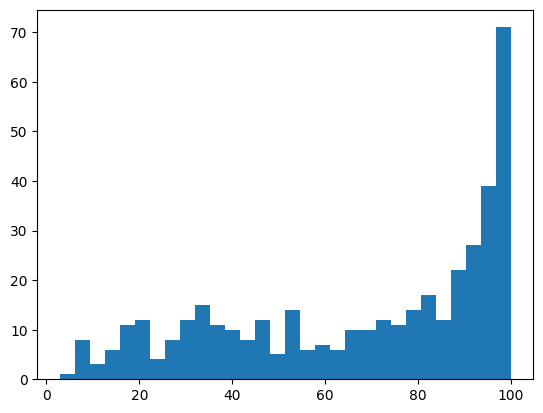

In [13]:
plt.hist(x_train['age'], bins = 30)
plt.show()

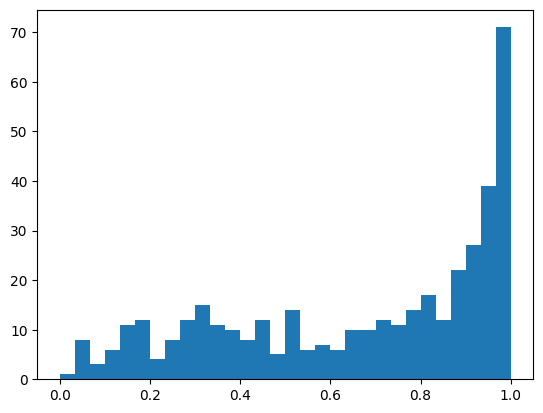

In [14]:
plt.hist(x_train_s1['age'], bins = 30)
plt.show()

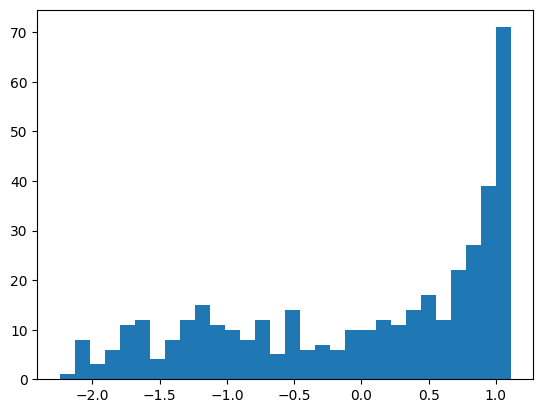

In [15]:
plt.hist(x_train_s2['age'], bins = 30)
plt.show()

## **3. 모델링**

### (1) import

In [16]:
# 모델링용
from sklearn.neighbors import KNeighborsRegressor  # KNeighborsClassifier

# 회귀모델 평가용
from sklearn.metrics import * # 모든 함수 다 불러와~

### (2) 모델선언

In [17]:
model = KNeighborsRegressor(n_neighbors = 3) # n_neighbors = k값

### (3) 모델링(학습)

In [18]:
model.fit(x_train_s1, y_train)

KNeighborsRegressor(n_neighbors=3)

### (4) 검증 : 예측

In [19]:
pred = model.predict(x_val_s1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


### (5) 검증 : 평가

In [20]:
# MSE
mean_squared_error( y_val, pred   )

17.848485838779958

In [21]:
# RMSE
# mean_squared_error(y_val, pred, squared=False)
root_mean_squared_error(y_val, pred)

4.224746837241251

In [22]:
# MAE 평균 오차
mean_absolute_error(y_val, pred )

2.8088235294117645

In [23]:
# MAPE : 평균 오차율
mean_absolute_percentage_error(y_val, pred )

0.1396640686039094

In [24]:
# 1 - MAPE : 정확도
1 - mean_absolute_percentage_error(y_val, pred )

0.8603359313960905

## **4. 복습문제**

* n_neighbors : k 의 갯수. k가 달라지면 예측결과도 달라고, 성능도 달라집니다!
* metric : 거리계산 방식.
    * euclidean : 유클리디안 거리 :  sqrt(a^2 + b^2)
    * manhattan : 맨하탄거리 : a + b
    * minkowski : 위 두가지 거리계산법에 대한 일반화 식

* model1 : n_neighbors = 5

In [29]:
model1 = KNeighborsRegressor(n_neighbors = 5)
print(model1.fit(x_train_s1, y_train))
pred1 = model1.predict(x_val_s1)

KNeighborsRegressor()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [31]:
# MSE
print(mean_squared_error( y_val, pred1  ))

# RMSE
print(root_mean_squared_error(y_val, pred1))

# MAE 평균오차
print(mean_absolute_error(y_val, pred1 ))

# MAPE : 평균오차율
print(mean_absolute_percentage_error(y_val, pred1 ))

# 1- MAPE : 정확도
print(1 - mean_absolute_percentage_error(y_val, pred1 ))


23.609235294117646
4.858933555227694
2.9915686274509796
0.14931628494923335
0.8506837150507667


* model2 : n_neighbors = 10


In [34]:
model2 = KNeighborsRegressor(n_neighbors = 10)
print(model2.fit(x_train_s1, y_train))
pred2 = model2.predict(x_val_s1)

KNeighborsRegressor(n_neighbors=10)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [35]:
# MSE
print(mean_squared_error( y_val, pred2  ))

# RMSE
print(root_mean_squared_error(y_val, pred2))

# MAE 평균오차
print(mean_absolute_error(y_val, pred2 ))

# MAPE : 평균오차율
print(mean_absolute_percentage_error(y_val, pred2 ))

# 1- MAPE : 정확도
print(1 - mean_absolute_percentage_error(y_val, pred2 ))

22.21652058823529
4.713440419506254
3.1418627450980385
0.14978505676962653
0.8502149432303735


* model3 : n_neighbors = 15


In [37]:
model3 = KNeighborsRegressor(n_neighbors = 15)
print(model3.fit(x_train_s1, y_train))
pred3 = model3.predict(x_val_s1)

KNeighborsRegressor(n_neighbors=15)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [38]:
# MSE
print(mean_squared_error( y_val, pred3  ))

# RMSE
print(root_mean_squared_error(y_val, pred3))

# MAE 평균오차
print(mean_absolute_error(y_val, pred3 ))

# MAPE : 평균오차율
print(mean_absolute_percentage_error(y_val, pred3 ))

# 1- MAPE : 정확도
print(1 - mean_absolute_percentage_error(y_val, pred3 ))

22.634252723311544
4.7575469228701825
3.260784313725491
0.15493308949644774
0.8450669105035522


* model1,2,3의 성능을 비교해 봅시다.

In [ ]:
# KNN(K-Nearest Neighbor) 회귀 모델에서 MSE(Mean Squared Error, 평균 제곱 오차)가 높을수록 모델의 예측 성능이 낮다는 것을 의미한다.
# 이때, model1,2,3 중 model2가 MSE가 가장 낮으므로, 예측 성능이 가장 높을 것을 알 수 있다.

# RMSE(Root Mean Squared Error, 평균 제곱근 오차)가 높을수록 모델의 예측 성능이 낮고 실제값과의 오차가 크다는 것을 의미하며, 이상치에 대한 민감성이 높다.
# 따라서 model1,2,3중 model2가 가장 낮으므로 예측성능이 가장 우수하다는 것을 알 수 있다.

In [ ]:
# MAE역시 높을 수록 모델의 예측 성능이 낮다는 것을 의미한다. MAE가 높을수록 데이터셋의 실제 값과 KNN이 예측한 값의 차이가 크기 때문에 모델이 불확실 하다.
# MAE에서는 model1,2,3 중 가장 낮은 model1이 가장 우수하며, 데이터의 패턴을 제대로 반영한다고 볼 수 있다.

# MAPE(Mean Absolute Percentage Error, 평균 절대 백분율 오차)가 높다는 것은 모델의 예측 정확도가 낮다(오차가 크다)는 것을 의미하며, 일반적으로 낮을 수 좋다.
# model1,2,3 중 model1이 세개의 모델 중 우수하며, model1이 실제 데이터와 가까운 값을 예측했다는 것을 알 수 있다.

In [ ]:
# 1-MAPE는 정확도로, MAPE가 낮을수록 좋은 모델이것과 반대로, 큰 값일 수록 좋은 모델임을 알 수 있다.